# Práctica 1 - Lingüística Computacional


### Importación de librerías

In [ ]:
# manejo de datos
import pandas as pd

# descarga de datos
import requests

# expresiones regulares
import re

# visualización
import matplotlib.pyplot as plt

# utilidades
from collections import defaultdict

# 1. Fonética

### 1.1 Descarga del diccionario IPA

In [2]:
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"

In [3]:
response = requests.get(IPA_URL.format(lang="es_MX"))

In [4]:
ipa_list = response.text.split("\n")

### 1.2 Exploración del corpus

In [5]:
ipa_list[0].split("\t")

['a', '/a/']

### 1.3 Función para descargar el diccionario fonético

In [6]:
def download_ipa_corpus(iso_lang: str) -> str:
    """
    Descarga el archivo del diccionario IPA para el idioma dado.
    """
    print(f"Descargando {iso_lang}...", end=" ")
    response = requests.get(IPA_URL.format(lang=iso_lang))
    print(f"status={response.status_code}")
    
    if response.status_code != 200:
        print(f"Error al descargar el corpus para {iso_lang}")
        return ""
    
    return response.text

### 1.4 Procesamiento del diccionario IPA

In [7]:
def parse_response(response: str) -> dict:
    """
    Convierte el texto crudo del diccionario IPA en un diccionario de Python.
    Formato esperado por línea: palabra[TAB]ipa
    """
    ipa_list = response.rstrip().split("\n")
    result = {}
    
    for item in ipa_list:
        if item == "":
            continue
        
        item_list = item.split("\t")
        
        if len(item_list) == 2:
            word, ipa = item_list
            result[word] = ipa
    
    return result

### 1.5 Construcción del diccionario fonético

In [9]:
es_data = parse_response(download_ipa_corpus("es_MX"))

Descargando es_MX... status=200


### 1.6 Consulta de transcripciones fonéticas

In [10]:
def get_ipa_transcriptions(word: str, dataset: dict) -> list[str]:
    """
    Busca una palabra en el diccionario y devuelve sus transcripciones IPA.
    Si no existe, devuelve lista vacía.
    """
    return dataset.get(word.lower(), "").split(", ") if dataset.get(word.lower(), "") else []

In [11]:
get_ipa_transcriptions("mayonesa", es_data)

['/maʝonesa/']

### 1.7 Distancia de Levenshtein

In [12]:
def levenshtein(s1: str, s2: str) -> int:
    """
    Calcula la distancia de Levenshtein entre dos cadenas.
    """
    m = len(s1)
    n = len(s2)

    dp = [[0 for _ in range(n + 1)] for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i - 1] == s2[j - 1]:
                costo = 0
            else:
                costo = 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + costo
            )

    return dp[m][n]

### 1.8 Búsqueda de la palabra más cercana

In [13]:
def encontrar_palabra_mas_cercana(palabra: str, dataset: dict) -> str:
    """
    Encuentra la palabra más cercana en el diccionario usando distancia de Levenshtein.
    """

    palabra_mas_cercana = None
    distancia_minima = float("inf")

    for palabra_dic in dataset.keys():
        distancia = levenshtein(palabra.lower(), palabra_dic.lower())

        if distancia < distancia_minima:
            distancia_minima = distancia
            palabra_mas_cercana = palabra_dic

    return palabra_mas_cercana

### 1.9 Obtención de transcripción aproximada

In [14]:
def obtener_ipa_aproximado(palabra: str, dataset: dict) -> dict:
    """
    Busca la transcripción IPA de una palabra.
    Si no existe en el diccionario, aproxima usando la palabra más cercana.
    """

    resultado_exacto = get_ipa_transcriptions(palabra, dataset)

    if resultado_exacto:
        return {
            "encontrada": True,
            "palabra_ingresada": palabra,
            "palabra_coincidente": palabra.lower(),
            "transcripciones": resultado_exacto
        }

    palabra_cercana = encontrar_palabra_mas_cercana(palabra, dataset)
    transcripcion_aprox = get_ipa_transcriptions(palabra_cercana, dataset)

    return {
        "encontrada": False,
        "palabra_ingresada": palabra,
        "palabra_coincidente": palabra_cercana,
        "transcripciones": transcripcion_aprox
    }

In [15]:
from pprint import pprint

### 1.10 Pruebas de búsqueda fonética aproximada

In [30]:
print(obtener_ipa_aproximado("tomate", es_data))
print(obtener_ipa_aproximado("ahua", es_data))
print(obtener_ipa_aproximado("cassa", es_data))
print(obtener_ipa_aproximado("cucharacha", es_data))

{'encontrada': True, 'palabra_ingresada': 'tomate', 'palabra_coincidente': 'tomate', 'transcripciones': ['/tomate/']}
{'encontrada': False, 'palabra_ingresada': 'ahua', 'palabra_coincidente': 'agua', 'transcripciones': ['/aɣwa/']}
{'encontrada': False, 'palabra_ingresada': 'cassa', 'palabra_coincidente': 'cansa', 'transcripciones': ['/kansa/']}
{'encontrada': False, 'palabra_ingresada': 'cucharacha', 'palabra_coincidente': 'cucaracha', 'transcripciones': ['/kukaɾatʃa/']}


# 2. Morfología

### 2.1 Configuración del corpus morfológico

In [18]:
# Lenguas disponibles en el corpus
LANGS = {
    "ces": "Czech",
    "eng": "English",
    "fra": "French",
    "hun": "Hungarian",
    "spa": "Spanish",
    "ita": "Italian",
    "lat": "Latin",
    "rus": "Russian",
}

# Categorías morfológicas del corpus
CATEGORIES = {
    "100": "Inflection",
    "010": "Derivation",
    "101": "Inflection, Compound",
    "000": "Root",
    "011": "Derivation, Compound",
    "110": "Inflection, Derivation",
    "001": "Compound",
    "111": "Inflection, Derivation, Compound",
}

### 2.2 Generación de nombres de archivos del corpus

In [19]:
def get_track_files(lang: str, track: str = "word") -> list[str]:
    """
    Genera los nombres de archivo del corpus SIGMORPHON
    según el idioma y el track.

    Parameters
    ----------
    lang : str
        Código de idioma (ej. "spa", "eng", "hun").

    track : str
        Tipo de datos del shared task (por defecto "word").

    Returns
    -------
    list[str]
        Lista de archivos del corpus para ese idioma.
    """

    return [
        f"{lang}.{track}.test.gold",
        f"{lang}.{track}.dev",
    ]

### 2.3 Descarga del corpus morfológico

In [20]:
def get_raw_corpus(files: list) -> list:
    """
    Descarga y concatena archivos TSV del corpus SIGMORPHON.

    Parameters
    ----------
    files : list
        Lista de nombres de archivos a descargar.

    Returns
    -------
    list
        Lista de líneas del corpus descargado.
    """

    result = []

    for file in files:
        print(f"Downloading {file}.tsv", end=" ")
        response = r.get(
            f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{file}.tsv"
        )
        print(f"status={response.status_code}")

        lines = response.text.split("\n")
        result.extend(lines[:-1])

    return result

### 2.4 Conversión del corpus a DataFrame

In [21]:
def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    """
    Convierte el corpus en un DataFrame para análisis.
    """

    data_list = []

    for line in corpus_list:

        try:
            word, tagged_data, category = line.split("\t")

        except ValueError:
            word, tagged_data = line.split("\t")
            category = "NOT_FOUND"

        morphemes = tagged_data.split()

        data_list.append(
            {
                "words": word,
                "morph": morphemes,
                "category": category,
                "lang": lang,
            }
        )

    df = pd.DataFrame(data_list)

    df["word_len"] = df["words"].apply(lambda word: len(word))
    df["morph_count"] = df["morph"].apply(lambda m: len(m))

    return df

### 2.5 Construcción del dataset morfológico

In [22]:
# Lenguas que analizaremos
langs = ["spa", "rus", "hun"]

In [23]:
dfs = []

for lang in langs:
    print(f"\nProcesando {lang} ({LANGS[lang]})")

    files = get_track_files(lang)
    raw = get_raw_corpus(files)

    df_lang = raw_corpus_to_dataframe(raw, lang=lang)
    dfs.append(df_lang)

df_all = pd.concat(dfs)

df_all.head()


Procesando spa (Spanish)

Procesando rus (Russian)

Procesando hun (Hungarian)


,words,morph,category,lang,word_len,morph_count
0,astronómica,"[astronómico, @@a]",100,spa,11,2
1,resignifiques,"[resignificar, @@es]",100,spa,13,2
2,importunamente,"[importuno, @@mente]",010,spa,14,2
3,conjeturaríamos,"[conjeturar, @@ría, @@amos]",100,spa,15,3
4,adquiridla,"[adquirir, @@id, @@la]",100,spa,10,3


### 2.6 Análisis del ratio morfemas/palabra

In [24]:
ratio = df_all.groupby("lang")["morph_count"].mean()

print("Ratio morfemas/palabra:")
print(ratio)

Ratio morfemas/palabra:
lang
hun    3.230282
rus    3.851561
spa    3.236228
Name: morph_count, dtype: float64


### 2.7 Porcentaje de flexión por idioma

In [25]:
inflection = (df_all["category"] == "100").groupby(df_all["lang"]).mean()

print("Porcentaje de flexión (100):")
print(inflection)

Porcentaje de flexión (100):
lang
hun    0.410923
rus    0.282761
spa    0.490071
Name: category, dtype: float64


### 2.8 Porcentaje de derivación por idioma

In [26]:
derivation = (df_all["category"] == "010").groupby(df_all["lang"]).mean()

print("Porcentaje de derivación (010):")
print(derivation)

Porcentaje de derivación (010):
lang
hun    0.029355
rus    0.094870
spa    0.033164
Name: category, dtype: float64


### 2.9 Visualización de la distribución morfológica

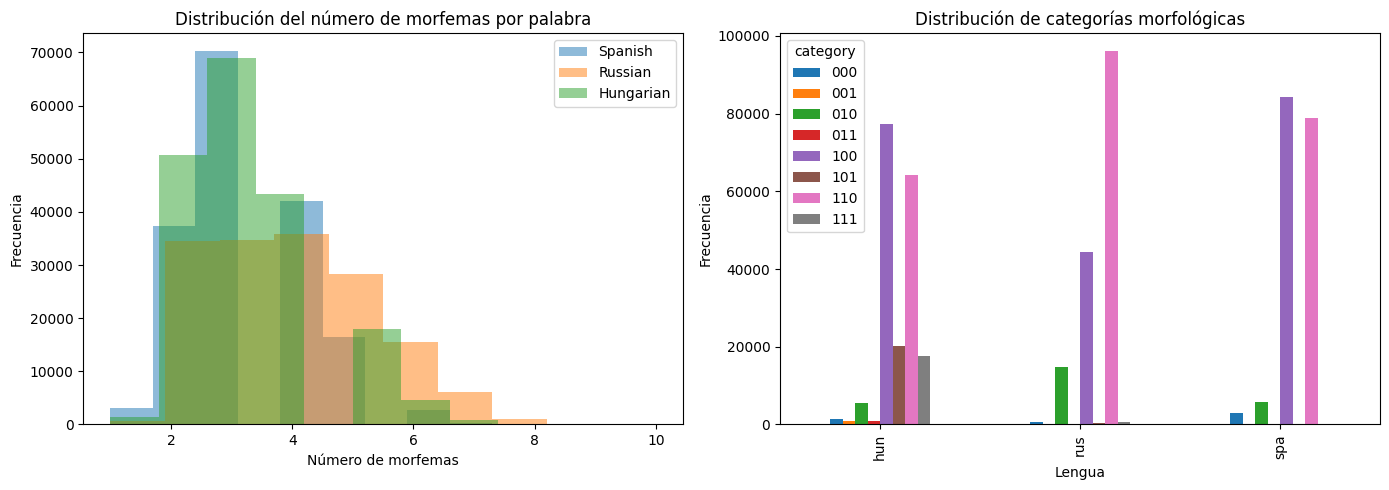

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Plot 1: número de morfemas por palabra
for lang in langs:
    subset = df_all[df_all["lang"] == lang]
    axes[0].hist(subset["morph_count"], bins=10, alpha=0.5, label=LANGS[lang])

axes[0].legend()
axes[0].set_title("Distribución del número de morfemas por palabra")
axes[0].set_xlabel("Número de morfemas")
axes[0].set_ylabel("Frecuencia")

# Plot 2: categorías morfológicas
category_counts = df_all.groupby(["lang","category"]).size().unstack(fill_value=0)

category_counts.plot(kind="bar", ax=axes[1])

axes[1].set_title("Distribución de categorías morfológicas")
axes[1].set_xlabel("Lengua")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## 3. Análisis 

<div style="text-align: justify;">
Para comparar el comportamiento morfológico de las lenguas analizadas se utilizaron dos tipos de evidencia: 
(1) el promedio de morfemas por palabra y 
(2) la distribución de las categorías morfológicas.

El promedio de morfemas por palabra es una medida aproximada de la complejidad morfológica. 

Cuando una lengua presenta palabras compuestas por varios morfemas segmentables, esto sugiere un sistema morfológico más productivo. 
En cambio, cuando las palabras tienden a estar formadas por uno o pocos morfemas, la morfología es menos segmentable y la lengua se acerca más al extremo aislante.

Los resultados muestran que el húngaro presenta el mayor número promedio de morfemas por palabra. 
Este comportamiento es consistente con su clasificación tipológica como lengua aglutinante. 
En las lenguas aglutinantes las palabras se construyen mediante la concatenación de múltiples morfemas, cada uno de los cuales suele expresar una función gramatical relativamente clara y separable.

En contraste, el español y el ruso presentan un número menor de morfemas por palabra. 
Ambas lenguas son tradicionalmente clasificadas como lenguas fusionales. 
En este tipo de lenguas un solo morfema puede expresar simultáneamente varias categorías gramaticales (por ejemplo persona, número y tiempo en una terminación verbal), lo que reduce la cantidad de segmentos morfológicos claramente identificables.

Las visualizaciones apoyan esta interpretación. 
La distribución del número de morfemas muestra que en húngaro aparecen con mayor frecuencia palabras compuestas por varios morfemas, mientras que en español y ruso predominan palabras con menos segmentos morfológicos. 
Esto refleja diferencias estructurales en la forma en que cada lengua codifica la información gramatical.
</div>

## 4. Conclusión

<div style="text-align: justify;">
Los resultados obtenidos muestran diferencias claras en la estructura morfológica de las lenguas analizadas. El húngaro presenta el mayor promedio de morfemas por palabra y una mayor frecuencia de palabras con múltiples segmentos morfológicos. Esto indica que su morfología tiende a organizar la información gramatical mediante la concatenación de varios morfemas dentro de una misma palabra.
<br><br>
En contraste, el español y el ruso presentan valores más bajos en el promedio de morfemas por palabra y una distribución más concentrada en palabras con pocos morfemas. Esto sugiere que, dentro del conjunto analizado, ambas lenguas se comportan de manera menos segmentada que el húngaro.

Por lo tanto, de las tres lenguas estudiadas, el húngaro es la que se aproxima más al comportamiento esperado de una lengua aglutinante, mientras que el español y el ruso se sitúan más lejos de ese patrón.
</div>